In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import torch
from safetensors.torch import load_file

# 모델 경로 설정
model_path = '/content/drive/MyDrive/청소년데이터/샘플데이터/코드/base2_model/model.safetensors'

# Safetensors 파일 로드
model = load_file(model_path)


In [ ]:
import pandas as pd

DF = pd.read_csv('/content/drive/MyDrive/청소년데이터/샘플데이터/A611.csv')
DF

,Sentence
0,하나 여보세요 돌려봐 아.
1,이케 개 강아지 왜 구지?
2,당신은 반려동물을 어린이 계층만 키우겠다는 의지를 맡아야 되는 건가요?
3,많은데 뭐예요 개발 저거도 행복해 보여요.
4,나도 부잣집 고양이로 태어나고 싶었어.
5,강아지는 활동적이어서 별로인 제 개는 시끄러워.
6,막 짖고 뛰어다니고 마고 산책시켜도 되고 똥 싸고 털은 날리고 완전 단점 구성이야.
7,완전 반려동물은 스크린 앞에서 봐야 이쁘죠.
8,미팅으로 가야 아름답어요.
9,날카로운 이빨로 네 손이 울어버렸죠.


In [5]:
import pandas as pd

In [10]:
# Load the CSV file
file_path = '/content/drive/MyDrive/청소년데이터/샘플데이터/텍스트문장부호/정리된_csv파일/A589_sentences.csv'
DF = pd.read_csv(file_path)

In [11]:
DF = DF.copy()
DF

,Sentence
0,"내가 시작하지 말라고 한 이유는, 이데아 주제로 롤 토체스에 대해 떠들려 했거든."
1,"그래서 패스를 샀는데, 테스트를 살지 말지 고민 중이야."
2,롤 패스를 사야 할지 말아야 할지 모르겠어.
3,"게임을 시작해 보려는 상황에서 내가 ""시작하지 말라"" 했던 거야."
4,"어, 그리고 내가 하는 것 중에서 서폿 같은 게 재밌을 것 같긴 한데, 뭔가 옛날에..."
5,예뻐서 갖고 싶긴 했어.
6,조이는 스킨들이 다 예쁘더라고.
7,그래서 지금도 고민 중이야.
8,"옛날에 비전 마법사 조이를 뽑았는데, 그 스킨이 예뻤거든."
9,그래서 연습을 하게 된다면 잘하고 싶은 마음도 있긴 해.


In [8]:
pip install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 16.9 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2024.10.0
    Uninstalling fsspec-2024.10.0:
      Successfully uninstalled fsspec-2024.10.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2024.10.0 requires fsspec==2024.10.0, but you have fsspec 2024.9.0 which is incompatible.


In [12]:
df = DF.rename(columns={'Sentence': 'sentence'})

In [13]:
from datasets import Dataset

# Huggingface Dataset 객체로 변환
dataset = Dataset.from_pandas(df)

In [14]:
from transformers import BertForSequenceClassification, BertTokenizer

# 토크나이저 준비
tokenizer = BertTokenizer.from_pretrained('klue/bert-base')

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/289 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/248k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/495k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/425 [00:00<?, ?B/s]

In [15]:
# 텍스트 데이터 토큰화
def tokenize_function(examples):
    return tokenizer(examples['sentence'], padding='max_length', truncation=True)


In [16]:
sample_datasets = dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/28 [00:00<?, ? examples/s]

# 가중치 확인

In [ ]:
# 가중치 키 확인
print("Keys in the SafeTensors file:")
print(model.keys())

Keys in the SafeTensors file:
dict_keys(['bert.embeddings.LayerNorm.bias', 'bert.embeddings.LayerNorm.weight', 'bert.embeddings.position_embeddings.weight', 'bert.embeddings.token_type_embeddings.weight', 'bert.embeddings.word_embeddings.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.dense.bias', 'bert.encoder.layer.0.attention.output.dense.weight', 'bert.encoder.layer.0.attention.self.key.bias', 'bert.encoder.layer.0.attention.self.key.weight', 'bert.encoder.layer.0.attention.self.query.bias', 'bert.encoder.layer.0.attention.self.query.weight', 'bert.encoder.layer.0.attention.self.value.bias', 'bert.encoder.layer.0.attention.self.value.weight', 'bert.encoder.layer.0.intermediate.dense.bias', 'bert.encoder.layer.0.intermediate.dense.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.dense.bias

In [ ]:
# 특정 가중치 확인 (예: 'linear.weight' 가중치)
key = 'classifier.weight'  # 사용하려는 키
tensor = model[key]


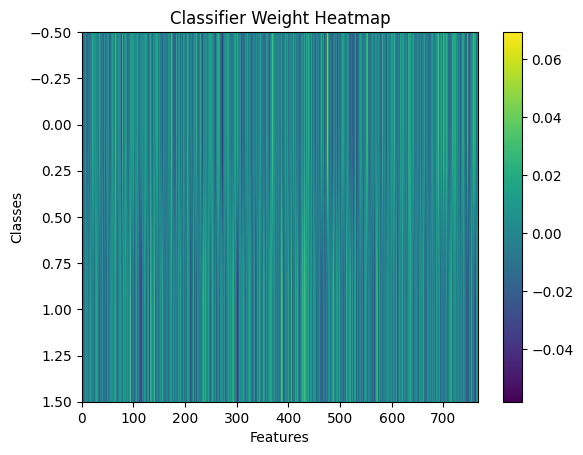

In [ ]:
# 가중치 행렬 시각화
import matplotlib.pyplot as plt

plt.imshow(tensor.numpy(), cmap='viridis', aspect='auto')
plt.colorbar()
plt.title('Classifier Weight Heatmap')
plt.xlabel('Features')
plt.ylabel('Classes')
plt.show()


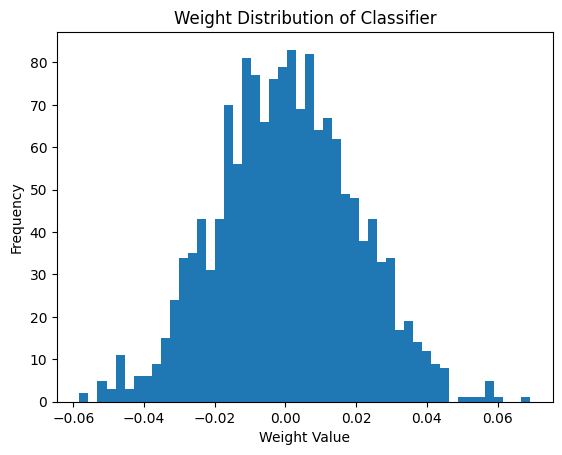

In [ ]:
# 히스토그램

plt.hist(tensor.numpy().flatten(), bins=50)
plt.title('Weight Distribution of Classifier')
plt.xlabel('Weight Value')
plt.ylabel('Frequency')
plt.show()


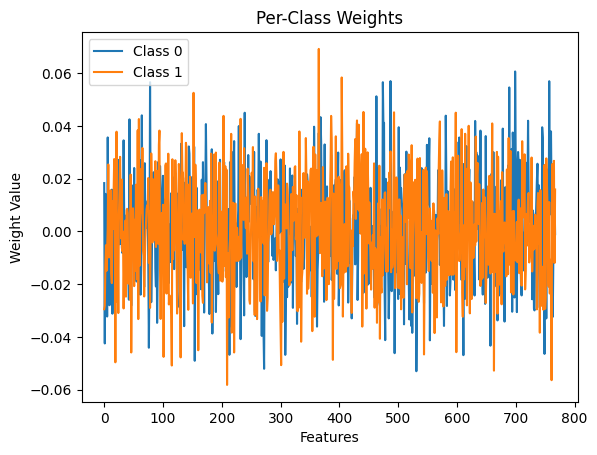

In [ ]:
for i, row in enumerate(tensor.numpy()):
    plt.plot(row, label=f'Class {i}')
plt.title('Per-Class Weights')
plt.xlabel('Features')
plt.ylabel('Weight Value')
plt.legend()
plt.show()


# 예측

In [17]:
model

{'bert.embeddings.LayerNorm.bias': tensor([-1.6271e-02, -6.4455e-03,  4.7155e-02, -1.3748e-02, -2.4957e-02,
         -3.2658e-02, -4.7431e-02, -1.4453e-02, -1.6483e-02,  6.4740e-03,
         -8.6323e-03, -3.5409e-02,  7.8520e-02,  3.6894e-03,  5.8440e-03,
         -2.3905e-02, -1.0803e-02,  3.5348e-02, -1.8304e-03,  1.2871e-02,
         -4.2299e-02, -1.1381e-02, -9.3973e-03, -2.5299e-03,  1.5998e-02,
          1.7342e-02, -1.8452e-02, -1.4991e-02, -9.4486e-04, -1.3581e-02,
         -1.2360e-02,  4.2131e-02, -2.6579e-02, -1.1902e-03, -2.1040e-02,
         -1.7943e-02, -3.3140e-02, -1.1108e-02, -2.5295e-02, -3.2554e-03,
          1.7953e-02,  1.3397e-03, -2.6679e-03,  2.8269e-04, -6.7183e-03,
          1.6145e-02,  4.2025e-04,  8.6181e-03,  4.4268e-03,  4.4446e-03,
          4.3903e-04,  7.9076e-03, -4.0828e-02, -7.1880e-03, -2.6163e-02,
         -4.8421e-04, -2.6037e-02,  7.5895e-03,  3.6249e-03, -5.5316e-05,
          2.6420e-03, -9.5591e-03, -3.1132e-03,  6.4407e-03,  2.9836e-03,
    

#모델 불러오기

In [18]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# klue/bert-base 모델과 토크나이저 로드
model_name = "klue/bert-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at klue/bert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [19]:
# 저장된 safetensors 가중치 로드
state_dict = load_file("/content/drive/MyDrive/청소년데이터/샘플데이터/코드/base2_model/model.safetensors")
model.load_state_dict(state_dict)

# 평가 모드로 전환
model.eval()

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(32000, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

In [20]:
df

,sentence
0,"내가 시작하지 말라고 한 이유는, 이데아 주제로 롤 토체스에 대해 떠들려 했거든."
1,"그래서 패스를 샀는데, 테스트를 살지 말지 고민 중이야."
2,롤 패스를 사야 할지 말아야 할지 모르겠어.
3,"게임을 시작해 보려는 상황에서 내가 ""시작하지 말라"" 했던 거야."
4,"어, 그리고 내가 하는 것 중에서 서폿 같은 게 재밌을 것 같긴 한데, 뭔가 옛날에..."
5,예뻐서 갖고 싶긴 했어.
6,조이는 스킨들이 다 예쁘더라고.
7,그래서 지금도 고민 중이야.
8,"옛날에 비전 마법사 조이를 뽑았는데, 그 스킨이 예뻤거든."
9,그래서 연습을 하게 된다면 잘하고 싶은 마음도 있긴 해.


In [21]:
# 텍스트 데이터를 토큰화하는 함수 (학습 시와 동일한 방식)
def tokenize_function(examples):
    return tokenizer(examples['sentence'], padding='max_length', truncation=True)

# 'sentence' 열을 리스트로 변환하여 토큰화
inputs = tokenizer(df["sentence"].tolist(),  # Series -> List[str]
                   padding='max_length', truncation=True, return_tensors="pt")

# 모델 추론 실행
with torch.no_grad():
    outputs = model(**inputs)

# 출력 로짓(logits) 값 및 예측 결과 확인
logits = outputs.logits
predicted_labels = torch.argmax(logits, dim=1)

print("Logits:", logits)
print("Predicted Labels:", predicted_labels)


Logits: tensor([[-0.4992,  0.2638],
        [-0.2857,  0.2693],
        [-0.4045,  0.2542],
        [-0.6389,  0.5633],
        [-1.0695,  0.7906],
        [ 0.3097, -0.1255],
        [-0.0607, -0.0049],
        [ 0.0114,  0.1538],
        [ 0.3631,  0.0720],
        [-0.5922,  0.4066],
        [-0.3384,  0.4649],
        [-1.3495,  0.8081],
        [-0.9447,  0.0724],
        [-1.3961,  1.0022],
        [-1.2977,  0.9879],
        [-0.0683,  0.2210],
        [-1.0877,  1.1070],
        [ 0.4041, -0.5503],
        [-1.3157,  1.3064],
        [-0.9360,  0.8038],
        [ 0.1608, -0.1634],
        [-0.1824,  0.5437],
        [-1.0498,  0.7234],
        [-1.0291,  0.5490],
        [-1.5498,  0.9288],
        [-1.6065,  0.9948],
        [-1.2876,  0.9778],
        [-0.8912,  0.0208]])
Predicted Labels: tensor([1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1,
        1, 1, 1, 1])


In [22]:
# Convert logits to a PyTorch Tensor

# Calculate probabilities for each item in the dataset
probabilities = torch.sigmoid(logits)[:, 1]


# To calculate the average probability for depression:
average_probability = probabilities.mean().item()
print(f"평균 우울증 증상 확률: {average_probability}")

평균 우울증 증상 확률: 0.6127539873123169


# 워드 클라우드

## A611 평균 우울증 증상 확률: 0.48

In [ ]:
!sudo apt-get install -y fonts-nanum # 폰트 설치
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf
# 한글 폰트
plt.rc('font', family='NanumBarunGothic')

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 49 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 0s (23.0 MB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 123630 files and direc

In [23]:
# Google Colab에서 한글 폰트 설치
!apt-get update -y
!apt-get install -y fonts-nanum

# 한글 폰트 경로 지정
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,626 B]
Get:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:6 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [1,192 kB]
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:8 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,626 kB]
Get:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Get:11 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Hit:12 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:13 https://r2u.stat.illinois.edu/u

In [25]:
pip install konlpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 93.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 493.8/493.8 kB 31.9 MB/s eta 0:00:00


In [26]:
from wordcloud import WordCloud # 워드 클라우드 생성을 위한 기본 모듈
from collections import Counter # 텍스트를 추출하고, 빈도 수 추출
from konlpy.tag import Okt, Mecab # 한국어 처리 형태소 분석 패키지
import pandas as pd
import matplotlib.pyplot as plt
import nltk
import re


from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

In [27]:
df

,sentence
0,"내가 시작하지 말라고 한 이유는, 이데아 주제로 롤 토체스에 대해 떠들려 했거든."
1,"그래서 패스를 샀는데, 테스트를 살지 말지 고민 중이야."
2,롤 패스를 사야 할지 말아야 할지 모르겠어.
3,"게임을 시작해 보려는 상황에서 내가 ""시작하지 말라"" 했던 거야."
4,"어, 그리고 내가 하는 것 중에서 서폿 같은 게 재밌을 것 같긴 한데, 뭔가 옛날에..."
5,예뻐서 갖고 싶긴 했어.
6,조이는 스킨들이 다 예쁘더라고.
7,그래서 지금도 고민 중이야.
8,"옛날에 비전 마법사 조이를 뽑았는데, 그 스킨이 예뻤거든."
9,그래서 연습을 하게 된다면 잘하고 싶은 마음도 있긴 해.


In [28]:
# 텍스트 컬럼 선택
texts = df['sentence']

# Okt 객체 생성 (한국어 형태소 분석기)
okt = Okt()

# 텍스트 전처리 함수
def preprocess_text(text):
    # 소문자 변환 (한국어에서는 필요 없지만 다른 언어가 포함될 수 있음)
    text = text.lower()
    # 특수 문자, 숫자 제거
    text = re.sub(r'[^가-힣\s]', '', text)
    return text

# 불용어 리스트 (필요에 따라 수정)
stopwords = set([
    '이', '그', '저', '것', '들', '나', '내', '너', '너희', '우리', '저희', '아니', '자기', '내가', '니가', '수가'
])

# 형태소 분석 후 불용어 제거
def tokenize_and_remove_stopwords(text):
    # 형태소 분석 (단어 단위로 분리)
    words = okt.morphs(text)
    # 불용어 제거
    words = [word for word in words if word not in stopwords]
    words = [n for n in words if len(n) > 1]  # 길이가 1인 단어 제거 (예: 조사)
    return ' '.join(words)

# 모든 텍스트에 대해 전처리 및 형태소 분석
processed_texts = texts.apply(preprocess_text).apply(tokenize_and_remove_stopwords)

# 모든 텍스트를 하나의 문자열로 결합
all_text = ' '.join(processed_texts)


In [44]:
import re
from konlpy.tag import Okt

# 업로드된 파일 읽기
with open('/content/drive/MyDrive/청소년데이터/stopword.txt', encoding='utf-8') as f:
    korean_stopwords = set(f.read().splitlines())

# Okt 객체 생성
okt = Okt()

# 텍스트 컬럼 선택
texts = df['sentence']

# 텍스트 전처리 함수
def preprocess_text(text):
    # 특수 문자, 숫자 제거
    text = re.sub(r'[^가-힣\s]', '', text)
    return text

# 형태소 분석 후 불용어 제거
def tokenize_and_remove_stopwords(text):
    words = okt.morphs(text)
    # 불용어 제거
    words = [word for word in words if word not in korean_stopwords]
    words = [word for word in words if len(word) > 1]
    return ' '.join(words)

# 모든 텍스트에 대해 전처리 및 형태소 분석
processed_texts = texts.apply(preprocess_text).apply(tokenize_and_remove_stopwords)

# 모든 텍스트를 하나의 문자열로 결합
all_text = ' '.join(processed_texts)


In [45]:
processed_texts

,sentence
0,시작 하지 라고 이유 이데아 주제 체스 대해 떠들려 했거든
1,패스 샀는데 테스트 고민 중이
2,패스 사야 할지 말아야 할지 모르겠어
3,게임 시작 보려는 상황 시작 하지 말라 했던 거야
4,하는 서폿 같은 재밌을 같긴 뭔가 옛날 플레스틴 조이 봤거든
5,예뻐서 갖고 싶긴 했어
6,조이는 스킨 예쁘 라고
7,지금 고민 중이
8,옛날 비전 마법사 조이 뽑았는데 스킨 예뻤거든
9,연습 하게 된다면 하고 싶은 마음 있긴


In [46]:
all_text

'시작 하지 라고 이유 이데아 주제 체스 대해 떠들려 했거든 패스 샀는데 테스트 고민 중이 패스 사야 할지 말아야 할지 모르겠어 게임 시작 보려는 상황 시작 하지 말라 했던 거야 하는 서폿 같은 재밌을 같긴 뭔가 옛날 플레스틴 조이 봤거든 예뻐서 갖고 싶긴 했어 조이는 스킨 예쁘 라고 지금 고민 중이 옛날 비전 마법사 조이 뽑았는데 스킨 예뻤거든 연습 하게 된다면 하고 싶은 마음 있긴 번은 해보고 싶기도 하고 스스로 부른 일이 라서 부담스럽 기도 성원 부른지 실력 아닌 같아 하려고 하는 줄이면 같은데 뭔가 아쉬워 대화 주제가 원래 탈스 대해 얘기 하려던 건데 이렇게 흘러간 건지 모르겠어 패스 살까 말까 계속 고민 인데 용돈 마다 지금 오만 내면 있거든 너무 흔한 싫고 나름 특별한 좋을 같아 구매 결정 하긴 해야겠지 캐릭터 키우면 귀여울까 싶다가도 생길 같아서 고민 이야 배경 이라도 예쁘면 좋을 텐데 그림 별로 유튜브 보기 하고 이리저리 비교 보고 있어 에는 마스코트 골랐는데 경험치 많이 얻어서 빨리 레벨 업도 하고 싶거든 요즘 게임 너무 어렵 라고 고속 돌리기로 하면 쉽게 있을 같은데 모르겠어 영화 이야기 나왔는데 짜리 영화 부담스러워 영화 보면 일찍 나가야 해서 피곤할 같아 애매해서 그냥 고민 하고 있는 중이 이렇게 문맥 정리 니까 결정 내려야 많네'

In [63]:
# 워드클라우드 생성
wordcloud = WordCloud(width=800, height=400, background_color='white', font_path=font_path, colormap='seismic').generate(all_text)

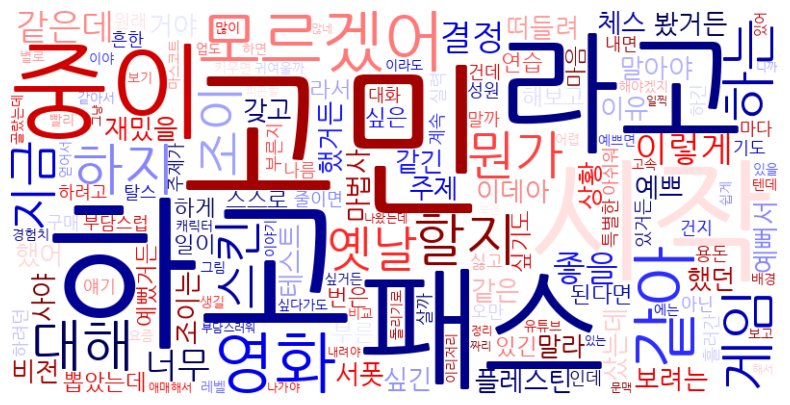

In [64]:
# 워드클라우드 시각화
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  # 축 숨기기
plt.show()

In [ ]:
c = Counter(all_text) # 위에서 얻은 words를 처리하여 단어별 빈도수 형태의 딕셔너리 데이터를 구함
print(c)

counts = Counter(c)
tags = counts.most_common(100)
print(type(tags))
for j in tags:
    print(j)

Counter({' ': 237, '고': 29, '지': 22, '어': 18, '아': 16, '이': 15, '다': 14, '는': 14, '기': 11, '하': 10, '요': 10, '도': 10, '서': 10, '동': 9, '면': 9, '있': 9, '물': 8, '생': 8, '없': 8, '나': 7, '려': 7, '야': 7, '가': 7, '데': 7, '개': 7, '니': 7, '게': 7, '강': 6, '되': 6, '로': 6, '으': 6, '구': 5, '반': 5, '은': 5, '먹': 5, '잖': 5, '뺏': 5, '여': 4, '보': 4, '우': 4, '거': 4, '해': 4, '리': 4, '죠': 4, '주': 4, '긴': 4, '돼': 4, '신': 3, '키': 3, '겠': 3, '양': 3, '시': 3, '러': 3, '전': 3, '에': 3, '운': 3, '라': 3, '습': 3, '진': 3, '관': 3, '심': 3, '사': 3, '금': 3, '온': 3, '을': 3, '그': 3, '린': 2, '계': 2, '의': 2, '부': 2, '태': 2, '싶': 2, '었': 2, '워': 2, '마': 2, '켜': 2, '날': 2, '완': 2, '크': 2, '쁘': 2, '미': 2, '누': 2, '간': 2, '직': 2, '장': 2, '짜': 2, '인': 2, '방': 2, '상': 2, '한': 2, '오': 2, '모': 2, '바': 2, '파': 2, '알': 2, '않': 2, '외': 2, '히': 2, '겼': 2, '까': 2, '육': 2, '질': 2, '뻥': 2, '팬': 2, '덤': 2, '세': 1, '돌': 1, '케': 1, '당': 1, '층': 1, '맡': 1, '건': 1, '많': 1, '예': 1, '발': 1, '행': 1, '복': 1, '잣': 1, '집': 1, '활': 1, '별': 1, '끄': 1, '